0. 套件載入與資料讀取
主要目的：匯入必要套件與車禍資料，並建立基本 DataFrame

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import geopandas as gpd

# 中文字體設定（讓圖表顯示中文）
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 讀取資料
file_path = "C:\\Users\\dcfoa\\OneDrive\\桌面\\Accident-Taipei\\accident_grouped.xlsx"  # 改成你自己的路徑
df = pd.read_excel(file_path, engine="openpyxl")

# 欄位命名統一
df = df.rename(columns={
    "發生月": "month",
    "發生日": "day",
    "發生時-Hours": "hour",
    "發生分": "minute",
    "肇事地點": "location_text",
    "事故類型及型態": "accident_type",
    "區序": "district",
    "座標-X": "x",
    "座標-Y": "y",
    "天候": "weather",
    "道路型態": "road_type",
    "傷亡人數": "casualties"
})

# 清理資料
df = df.dropna(subset=["x", "y", "hour"])
df["hour"] = df["hour"].astype(int)
df["district"] = df["district"].astype(str)

print("✅ 資料筆數：", len(df))
print("✅ 欄位：", list(df.columns))

✅ 資料筆數： 22357
✅ 欄位： ['month', 'day', 'hour', 'minute', 'location_text', '死亡人數', '受傷人數', 'accident_type', 'district', 'weather', 'road_type', 'x', 'y', 'casualties']


1. 各行政區車禍數量統計
主要目的：統計每個行政區一年中車禍總數，並以長條圖顯示

C:\Users\dcfoa\AppData\Local\Temp\ipykernel_15108\3680014815.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="行政區", y="車禍數量", data=area_counts, palette="coolwarm")


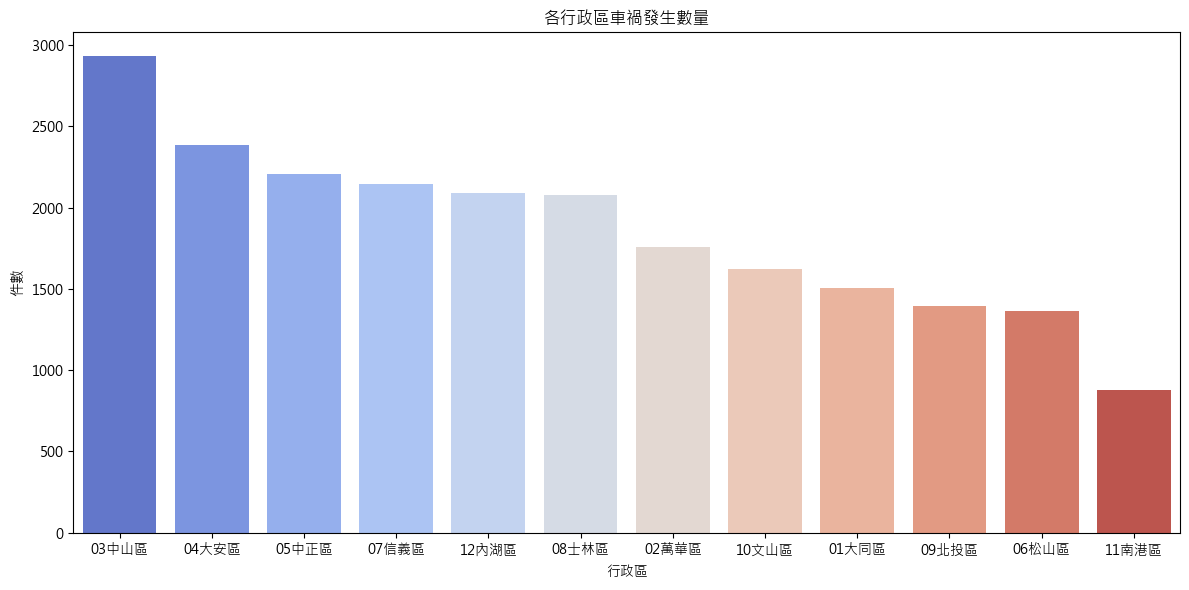

In [24]:
area_counts = df["district"].value_counts().reset_index()
area_counts.columns = ["行政區", "車禍數量"]

plt.figure(figsize=(12, 6))
sns.barplot(x="行政區", y="車禍數量", data=area_counts, palette="coolwarm")
plt.title("各行政區車禍發生數量")
plt.xlabel("行政區")
plt.ylabel("件數")
plt.tight_layout()
plt.show()

2. 各時段車禍分布
主要目的：觀察每日不同時段的車禍發生趨勢

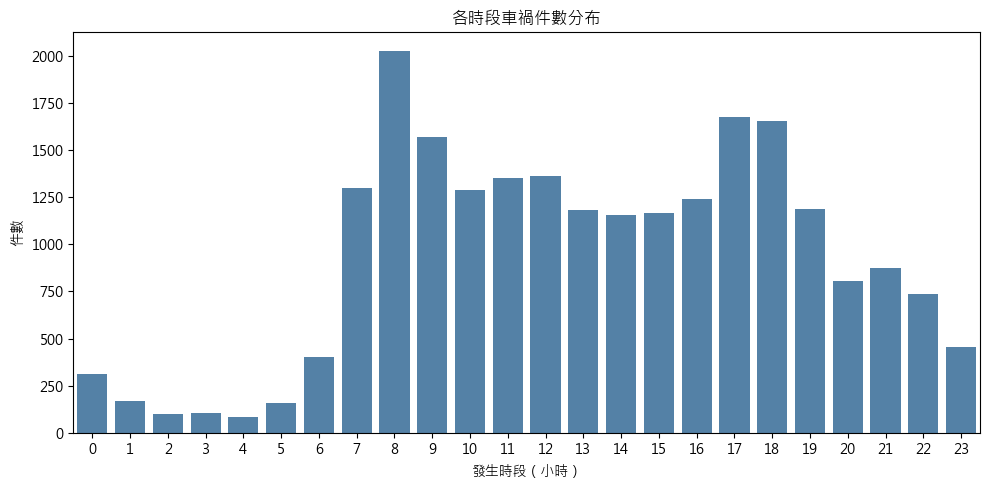

In [25]:
hour_counts = df.groupby("hour").size().reset_index(name="件數")

plt.figure(figsize=(10, 5))
sns.barplot(x="hour", y="件數", data=hour_counts, color="steelblue")
plt.title("各時段車禍件數分布")
plt.xlabel("發生時段（小時）")
plt.ylabel("件數")
plt.tight_layout()
plt.show()

3. 前10大事故類型
主要目的：分析最常發生的事故型態

C:\Users\dcfoa\AppData\Local\Temp\ipykernel_15108\4033582996.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="事故類型", x="件數", data=type_counts, palette="Reds_r")


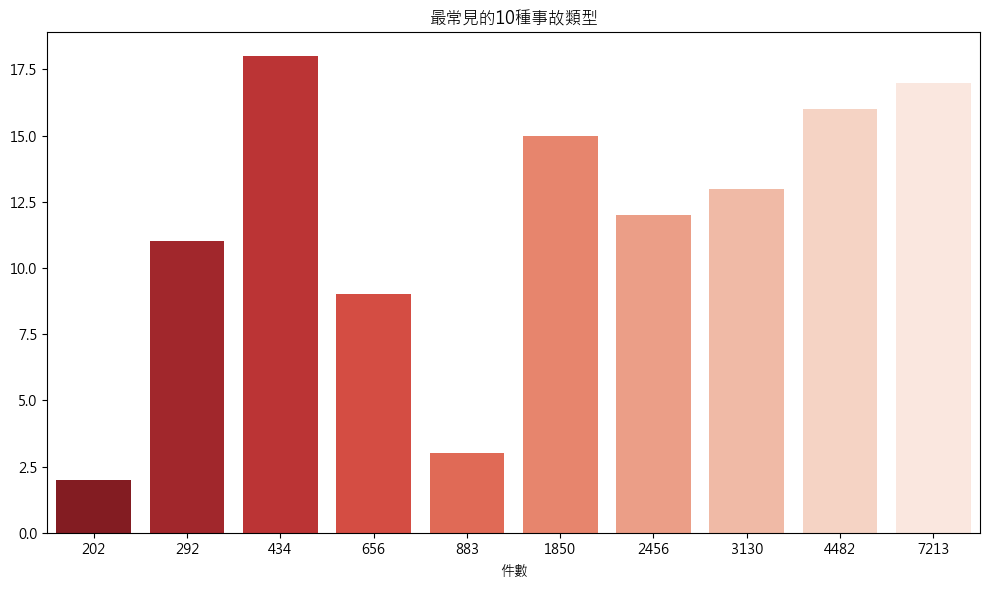

In [26]:
type_counts = df["accident_type"].value_counts().head(10).reset_index()
type_counts.columns = ["事故類型", "件數"]

plt.figure(figsize=(10, 6))
sns.barplot(y="事故類型", x="件數", data=type_counts, palette="Reds_r")
plt.title("最常見的10種事故類型")
plt.xlabel("件數")
plt.ylabel("")
plt.tight_layout()
plt.show()

4. 熱點分布地圖（全市 or 可切換行政區）
主要目的：以 Folium 顯示事故地點分布與密度熱區

In [27]:
# 建立中心座標（台北市中心）
center = [25.04, 121.54]

# 互動式行政區選擇
district_list = sorted(df["district"].unique())
print("可選行政區：", district_list)

# 手動輸入或切換行政區
selected_district = input("請輸入要顯示的行政區（留空代表全市）: ").strip()
if selected_district:
    map_df = df[df["district"] == selected_district]
    title = f"{selected_district} 行政區車禍熱點分布"
else:
    map_df = df.copy()
    title = "台北市車禍熱點分布"

# 建立地圖
m = folium.Map(location=center, zoom_start=12, tiles="CartoDB Positron")

# 加入熱點層
heat_data = map_df[["y", "x"]].values.tolist()
HeatMap(heat_data, radius=8, blur=15).add_to(m)

# 加上標題
title_html = f"""
             <h3 align="center" style="font-size:18px"><b>{title}</b></h3>
             """
m.get_root().html.add_child(folium.Element(title_html))

# 顯示地圖
m.save("accident_hotspots.html")

可選行政區： ['01大同區', '02萬華區', '03中山區', '04大安區', '05中正區', '06松山區', '07信義區', '08士林區', '09北投區', '10文山區', '11南港區', '12內湖區']


5. 預測模型：未來24小時車禍風險
主要目的：以時間與空間分布預測未來 24 小時高風險熱點

In [28]:
from datetime import datetime, timedelta

# ================================================
# 🔮 時間風險（每區每小時發生比例）- 安全寫法
# ================================================
# 先算每區總數
district_totals = df.groupby("district").size().rename("total")
# 再算每區各時段數量
hour_risk = (
    df.groupby(["district", "hour"])
      .size()
      .reset_index(name="count")
      .merge(district_totals, on="district", how="left")
)
hour_risk["hour_risk"] = hour_risk["count"] / hour_risk["total"]
hour_risk = hour_risk[["district", "hour", "hour_risk"]]

# ================================================
# 📍 空間風險（每區群中心）
# ================================================
bin_size = 0.002
df["x_bin"] = (df["x"] / bin_size).round()
df["y_bin"] = (df["y"] / bin_size).round()

space_risk = (
    df.groupby(["district", "x_bin", "y_bin"])
      .size()
      .reset_index(name="count")
)
# 每區總數
dist_total = space_risk.groupby("district")["count"].sum().rename("total")
space_risk = space_risk.merge(dist_total, on="district", how="left")
space_risk["space_risk"] = space_risk["count"] / space_risk["total"]
space_risk = space_risk[["district", "x_bin", "y_bin", "space_risk"]]

# ================================================
# 🕒 未來24小時（以當前時間為基準）
# ================================================
future_hours = [(datetime.now() + timedelta(hours=i)).hour for i in range(1, 25)]

forecast = (
    hour_risk[hour_risk["hour"].isin(future_hours)]
    .merge(space_risk, on="district", how="inner")
)

# ================================================
# ⚙️ 計算風險分數
# ================================================
forecast["risk_score"] = forecast["hour_risk"] * forecast["space_risk"]
forecast["risk_score"] = forecast["risk_score"] / forecast["risk_score"].max()

# 取前50筆最高風險熱點
forecast_sorted = forecast.sort_values("risk_score", ascending=False).head(50)
forecast_sorted.head()


,district,hour,hour_risk,x_bin,y_bin,space_risk,risk_score
920,01大同區,8,0.092961,60754.0,12525.0,0.047809,1.000000
1946,01大同區,17,0.082337,60754.0,12525.0,0.047809,0.885714
54245,11南港區,8,0.122007,60804.0,12527.0,0.030787,0.845158
54168,11南港區,8,0.122007,60791.0,12526.0,0.030787,0.845158
54279,11南港區,8,0.122007,60808.0,12527.0,0.029647,0.813856


6. 預測結果地圖輸出 (HTML)
主要目的：將未來24小時高風險熱點在地圖上可視化

In [30]:
# ================================================
# 🌐 互動預測地圖（可在 HTML 內自由切換行政區）
# 主要目的：
# 1) 以時間風險 × 空間風險做出 risk_score（0~1）
# 2) 每個行政區做一個圖層（FeatureGroup），可在地圖中切換顯示
# 3) 依風險值上色（漸層），加上圖例
# 4) 每區只顯示前 K 筆（預設 5）高風險點，避免地圖太擁擠
# ================================================
import folium
from folium import FeatureGroup
from folium.plugins import HeatMap
import numpy as np
from datetime import datetime, timedelta
import branca.colormap as cm

# ---------- 1) 風險計算（與你先前一致，但為安全起見這裡再組一次） ----------
# 每區 × 每小時 的比例
district_totals = df.groupby("district").size().rename("total")
hour_risk = (
    df.groupby(["district", "hour"])
      .size().reset_index(name="count")
      .merge(district_totals, on="district", how="left")
)
hour_risk["hour_risk"] = hour_risk["count"] / hour_risk["total"]
hour_risk = hour_risk[["district", "hour", "hour_risk"]]

# 空間格網（經緯度分箱）
bin_size = 0.001   # 調這裡可變換熱點聚合程度（越小越密）
df["x_bin"] = (df["x"] / bin_size).round()
df["y_bin"] = (df["y"] / bin_size).round()

space_risk = (
    df.groupby(["district", "x_bin", "y_bin"])
      .size().reset_index(name="count")
)
dist_total = space_risk.groupby("district")["count"].sum().rename("total")
space_risk = space_risk.merge(dist_total, on="district", how="left")
space_risk["space_risk"] = space_risk["count"] / space_risk["total"]
space_risk = space_risk[["district", "x_bin", "y_bin", "space_risk"]]

# 未來 24 小時（以執行時刻為基準）
future_hours = [(datetime.now() + timedelta(hours=i)).hour for i in range(1, 25)]
forecast = (
    hour_risk[hour_risk["hour"].isin(future_hours)]
    .merge(space_risk, on="district", how="inner")
)

# 綜合風險分數（0~1）
forecast["risk_score"] = forecast["hour_risk"] * forecast["space_risk"]
max_rs = forecast["risk_score"].max()
forecast["risk_score"] = forecast["risk_score"] / max_rs if max_rs > 0 else 0.0

# 轉為可畫點的實座標（用格網中心）
forecast["lat"] = forecast["y_bin"] * bin_size
forecast["lng"] = forecast["x_bin"] * bin_size

# 每區前 K 筆
PER_DISTRICT_TOP_K = 5
forecast_top = (
    forecast.sort_values(["district", "risk_score"], ascending=[True, False])
            .groupby("district", as_index=False)
            .head(PER_DISTRICT_TOP_K)
            .copy()
)

# ---------- 2) 地圖底圖 & 顏色梯度 ----------
center = [25.04, 121.54]  # 台北市中心
m_forecast = folium.Map(location=center, zoom_start=12, tiles="CartoDB Positron")

# 顏色梯度（0→1）
cmap = cm.linear.YlOrRd_09.scale(0, 1)   # 黃→紅
cmap.caption = "風險值（相對分數 0–1）"
cmap.add_to(m_forecast)

# ---------- 3) 依行政區建立圖層，可在 HTML 內切換 ----------
popup_width = 240  # 你想要的 popup 寬度
radius_base = 5    # 基礎半徑
radius_scale = 12  # 風險對應的加乘

districts = sorted(forecast_top["district"].unique())
for dist in districts:
    grp = FeatureGroup(name=f"{dist}（前{PER_DISTRICT_TOP_K}）", show=True)  # 預設顯示，可改 show=False
    dsub = forecast_top[forecast_top["district"] == dist]

    for _, row in dsub.iterrows():
        r = float(row["risk_score"])
        color = cmap(r)
        popup_html = f"""
        <div style="width:{popup_width}px; font-size:13px; line-height:1.5;">
            <b>行政區：</b>{row['district']}<br>
            <b>風險值：</b>{r:.3f}<br>
            <b>時段：</b>{int(row['hour'])} 時
        </div>
        """
        folium.CircleMarker(
            location=[row["lat"], row["lng"]],
            radius=radius_base + r * radius_scale,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.6,
            popup=folium.Popup(popup_html, max_width=popup_width+40),
        ).add_to(grp)

    grp.add_to(m_forecast)

# （可選）全市 TopN 額外一層
CITY_TOP_N = 50
city_top = forecast.sort_values("risk_score", ascending=False).head(CITY_TOP_N).copy()
grp_city = FeatureGroup(name=f"全市 Top{CITY_TOP_N}", show=False)
for _, row in city_top.iterrows():
    r = float(row["risk_score"])
    color = cmap(r)
    popup_html = f"""
    <div style="width:{popup_width}px; font-size:13px; line-height:1.5;">
        <b>行政區：</b>{row['district']}<br>
        <b>風險值：</b>{r:.3f}<br>
        <b>時段：</b>{int(row['hour'])} 時
    </div>
    """
    folium.CircleMarker(
        location=[row["y_bin"] * bin_size, row["x_bin"] * bin_size],
        radius=radius_base + r * radius_scale,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.5,
        popup=folium.Popup(popup_html, max_width=popup_width+40),
    ).add_to(grp_city)
grp_city.add_to(m_forecast)

# LayerControl 讓你在 HTML 內自由勾選行政區
folium.LayerControl(collapsed=False).add_to(m_forecast)

# 輸出 HTML
m_forecast.save("accident_forecast_interactive.html")
m_forecast
